------
**You cannot save any changes you make to this file, so please make sure to save it on your Google Colab drive or download it as a .ipynb file.**

------



Practical 1: Sentiment Detection in Movie Reviews
========================================



This practical concerns detecting sentiment in movie reviews. This is a typical NLP classification task.
In [this file](https://gist.githubusercontent.com/bastings/d47423301cca214e3930061a5a75e177/raw/5113687382919e22b1f09ce71a8fecd1687a5760/reviews.json) (80MB) you will find 1000 positive and 1000 negative **movie reviews**.
Each review is a **document** and consists of one or more sentences.

To prepare yourself for this practical, you should
have a look at a few of these texts to understand the difficulties of
the task: how might one go about classifying the texts? You will write
code that decides whether a movie review conveys positive or
negative sentiment.

Please make sure you have read the following paper:

>   Bo Pang, Lillian Lee, and Shivakumar Vaithyanathan
(2002).
[Thumbs up? Sentiment Classification using Machine Learning
Techniques](https://dl.acm.org/citation.cfm?id=1118704). EMNLP.

Bo Pang et al. introduced the movie review sentiment
classification task, and the above paper was one of the first papers on
the topic. The first version of your sentiment classifier will do
something similar to Pang et al.'s system. If you have questions about it,
you should resolve you doubts as soon as possible with your TA.


**Advice**

Please read through the entire practical and familiarise
yourself with all requirements before you start coding or otherwise
solving the tasks. Writing clean and concise code can make the difference
between solving the assignment in a matter of hours, and taking days to
run all experiments.


**Implementation**

While we inserted code cells to indicate where you should implement your own code, please feel free to add/remove code blocks where you see fit (but make sure that the general structure of the assignment is preserved). Also, please keep in mind that it is always good practice to structure your code properly, e.g., by implementing separate classes and functions that can be reused. **Make sure you run all your code before submitting the notebook, and do not leave unnecessary print statements / cells in your notebook that are not intended for the grader.**

## Environment

All code should be written in **Python 3**.
This is the default in Google Colab.

In [1]:
!python --version

Python 3.10.12


If you want to run code on your own computer, then download this notebook through `File -> Download .ipynb`.
The easiest way to
install Python is through downloading
[Anaconda](https://www.anaconda.com/download).
After installation, you can start the notebook by typing `jupyter notebook filename.ipynb`.
You can also use an IDE
such as [PyCharm](https://www.jetbrains.com/pycharm/download/) to make
coding and debugging easier. It is good practice to create a [virtual
environment](https://docs.python.org/3/tutorial/venv.html) for this
project, so that any Python packages don’t interfere with other
projects.


**Learning Python 3**

If you are new to Python 3, you may want to check out a few of these resources:
- https://learnxinyminutes.com/docs/python3/
- https://www.learnpython.org/
- https://docs.python.org/3/tutorial/

In [2]:
import math
import os
import sys
from subprocess import call
from nltk import FreqDist
from nltk.util import ngrams
from nltk.stem.porter import PorterStemmer
import sklearn as sk
from google.colab import drive
import pickle
import json
from collections import Counter
import requests
import matplotlib.pyplot as plt
import numpy as np

## Loading the data

**Download the sentiment lexicon and the movie reviews dataset.**

In [3]:
# # download sentiment lexicon
!wget https://gist.githubusercontent.com/bastings/d6f99dcb6c82231b94b013031356ba05/raw/f80a0281eba8621b122012c89c8b5e2200b39fd6/sent_lexicon
# # download review data
!wget https://gist.githubusercontent.com/bastings/d47423301cca214e3930061a5a75e177/raw/5113687382919e22b1f09ce71a8fecd1687a5760/reviews.json

--2024-11-13 17:28:31--  https://gist.githubusercontent.com/bastings/d6f99dcb6c82231b94b013031356ba05/raw/f80a0281eba8621b122012c89c8b5e2200b39fd6/sent_lexicon
Resolving gist.githubusercontent.com (gist.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to gist.githubusercontent.com (gist.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 662577 (647K) [text/plain]
Saving to: ‘sent_lexicon’

sent_lexicon        100%[===================>] 647.05K  --.-KB/s    in 0.06s   

2024-11-13 17:28:31 (11.0 MB/s) - ‘sent_lexicon’ saved [662577/662577]

--2024-11-13 17:28:31--  https://gist.githubusercontent.com/bastings/d47423301cca214e3930061a5a75e177/raw/5113687382919e22b1f09ce71a8fecd1687a5760/reviews.json
Resolving gist.githubusercontent.com (gist.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to gist.githubusercontent.com (gist.githubusercontent.

**Load the movie reviews.**

Each word in a review comes with its part-of-speech tag. For documentation on POS-tags, see https://catalog.ldc.upenn.edu/docs/LDC99T42/tagguid1.pdf.


In [4]:
# file structure:
# [
#  {"cv": integer, "sentiment": str, "content": list}
#  {"cv": integer, "sentiment": str, "content": list}
#   ..
# ]
# where `content` is a list of sentences,
# with a sentence being a list of (token, pos_tag) pairs.


with open("reviews.json", mode="r", encoding="utf-8") as f:
  reviews = json.load(f)

def print_sentence_with_pos(s):
  print(" ".join("%s/%s" % (token, pos_tag) for token, pos_tag in s))

def show_document_statistics(reviews):
  print("Total number of reviews:", len(reviews), '\n')

  for i, r in enumerate(reviews):
    print(r["cv"], r["sentiment"], len(r["content"]))  # cv, sentiment, num sents
    print_sentence_with_pos(r["content"][0])
    if i == 5:
      break

  c = Counter()
  for review in reviews:
    for sentence in review["content"]:
      for token, pos_tag in sentence:
        c[token.lower()] += 1

  print("\nNumber of word types:", len(c))
  print("Number of word tokens:", sum(c.values()))

  print("\nMost common tokens:")
  for token, count in c.most_common(20):
    print("%10s : %8d" % (token, count))

show_document_statistics(reviews)


Total number of reviews: 2000 

0 NEG 29
Two/CD teen/JJ couples/NNS go/VBP to/TO a/DT church/NN party/NN ,/, drink/NN and/CC then/RB drive/NN ./.
1 NEG 11
Damn/JJ that/IN Y2K/CD bug/NN ./.
2 NEG 24
It/PRP is/VBZ movies/NNS like/IN these/DT that/WDT make/VBP a/DT jaded/JJ movie/NN viewer/NN thankful/JJ for/IN the/DT invention/NN of/IN the/DT Timex/NNP IndiGlo/NNP watch/NN ./.
3 NEG 19
QUEST/NN FOR/IN CAMELOT/NNP ``/`` Quest/NNP for/IN Camelot/NNP ''/'' is/VBZ Warner/NNP Bros./NNP '/POS first/JJ feature-length/JJ ,/, fully-animated/JJ attempt/NN to/TO steal/VB clout/NN from/IN Disney/NNP 's/POS cartoon/NN empire/NN ,/, but/CC the/DT mouse/NN has/VBZ no/DT reason/NN to/TO be/VB worried/VBN ./.
4 NEG 38
Synopsis/NNPS :/: A/DT mentally/RB unstable/JJ man/NN undergoing/VBG psychotherapy/NN saves/VBZ a/DT boy/NN from/IN a/DT potentially/RB fatal/JJ accident/NN and/CC then/RB falls/VBZ in/IN love/NN with/IN the/DT boy/NN 's/POS mother/NN ,/, a/DT fledgling/NN restauranteur/NN ./.
5 NEG 35
In/I

#(1) Lexicon-based approach (3.5pts)



A traditional approach to classify documents according to their sentiment is the lexicon-based approach. To implement this approach, you need a **sentiment lexicon**, i.e., a list of words annotated with a sentiment label (e.g., positive and negative, or a score from 0 to 5).

In this practical, you will use the sentiment
lexicon released by Wilson et al. (2005).

> Theresa Wilson, Janyce Wiebe, and Paul Hoffmann
(2005). [Recognizing Contextual Polarity in Phrase-Level Sentiment
Analysis](http://www.aclweb.org/anthology/H/H05/H05-1044.pdf). HLT-EMNLP.

Pay attention to all the information available in the sentiment lexicon. The field *word1* contains the lemma, *priorpolarity* contains the sentiment label (positive, negative, both, or neutral), *type* gives you the magnitude of the word's sentiment (strong or weak), and *pos1* gives you the part-of-speech tag of the lemma. Some lemmas can have multiple part-of-speech tags and thus multiple entries in the lexicon. The path of the lexicon file is `"sent_lexicon"`.


In [5]:
with open("sent_lexicon", mode="r", encoding="utf-8") as f:
  line_cnt = 0
  for line in f:
    print(line.strip())
    line_cnt += 1
    if line_cnt > 4:
      break

type=weaksubj len=1 word1=abandoned pos1=adj stemmed1=n priorpolarity=negative
type=weaksubj len=1 word1=abandonment pos1=noun stemmed1=n priorpolarity=negative
type=weaksubj len=1 word1=abandon pos1=verb stemmed1=y priorpolarity=negative
type=strongsubj len=1 word1=abase pos1=verb stemmed1=y priorpolarity=negative
type=strongsubj len=1 word1=abasement pos1=anypos stemmed1=y priorpolarity=negative


Lexica such as this can be used to solve
the classification task without using Machine Learning. For example, one might look up every word $w_1 ... w_n$ in a document, and compute a **binary score**
$S_{binary}$ by counting how many words have a positive or a
negative label in the sentiment lexicon $SLex$.

$$S_{binary}(w_1 w_2 ... w_n) = \sum_{i = 1}^{n}\text{sign}(SLex\big[w_i\big])$$

where $\text{sign}(SLex\big[w_i\big])$ refers to the polarity of $w_i$.

**Threshold.** On average, there are more positive than negative words per review (~7.13 more positive than negative per review) to take this bias into account you should use a threshold of **8** (roughly the bias itself) to make it harder to classify as positive.

$$
\text{classify}(S_{binary}(w_1 w_2 ... w_n)) = \bigg\{\begin{array}{ll}
        \text{positive} & \text{if } S_{binary}(w_1w_2...w_n) > threshold\\
        \text{negative} & \text{otherwise}
        \end{array}
$$


#### (Q1.1) Implement this approach and report its classification accuracy. (1 pt)

In [6]:
def create_lexic(path):
    lexic_dict={}
    with open(path, mode="r", encoding="utf-8") as f:
        for l in f:
            words=l.split(" ")
            typee=words[0].split('=')[1]
            word=words[2].split('=')[1]
            priorpo=words[-1].split("=")[1][:-1]
            lexic_dict[word]=[priorpo, typee]
    return lexic_dict

lexic_dict = create_lexic("sent_lexicon")
lexic_dict

{'abandoned': ['negative', 'weaksubj'],
 'abandonment': ['negative', 'weaksubj'],
 'abandon': ['negative', 'weaksubj'],
 'abase': ['negative', 'strongsubj'],
 'abasement': ['negative', 'strongsubj'],
 'abash': ['negative', 'strongsubj'],
 'abate': ['negative', 'weaksubj'],
 'abdicate': ['negative', 'weaksubj'],
 'aberration': ['negative', 'strongsubj'],
 'abhor': ['negative', 'strongsubj'],
 'abhorred': ['negative', 'strongsubj'],
 'abhorrence': ['negative', 'strongsubj'],
 'abhorrent': ['negative', 'strongsubj'],
 'abhorrently': ['negative', 'strongsubj'],
 'abhors': ['negative', 'strongsubj'],
 'abidance': ['positive', 'strongsubj'],
 'abide': ['positive', 'strongsubj'],
 'abject': ['negative', 'strongsubj'],
 'abjectly': ['negative', 'strongsubj'],
 'abjure': ['negative', 'weaksubj'],
 'abilities': ['positive', 'weaksubj'],
 'ability': ['positive', 'weaksubj'],
 'able': ['positive', 'weaksubj'],
 'abnormal': ['negative', 'weaksubj'],
 'abolish': ['negative', 'weaksubj'],
 'abominabl

In [7]:
def binary_score(review, lexicon):
    score=0
    count=0
    for s in review['content']:
        for token, pos in s:
            token = token.lower()
            if token in lexicon:
                polarity = lexicon[token][0]
                if polarity == 'positive':
                    score+= 1
                elif polarity == 'negative':
                    score-= 1
                count+= 1
    return score, count

def classification(reviews, lexicon, threshold):
    token_results=[]
    scores=[]
    counts=[]

    for r in reviews:
        true=r["sentiment"]
        score,count=binary_score(r, lexicon)
        scores.append(score)
        counts.append(count)
        pred= "POS" if score>threshold else "NEG"
        token_results.append(1 if (pred=="POS" and true == "POS") or (pred == "NEG" and true == "NEG") else 0)

    avg_score=np.mean(scores)
    avg_count= np.mean(counts)

    return token_results, avg_score, avg_count

In [8]:
# token_results should be a list of binary indicators; for example [1, 0, 1, ...]
# where 1 indicates a correct classification and 0 an incorrect classification.
token_results, avg_score, avg_count= classification(reviews, lexic_dict, threshold=8)
token_accuracy = sum(token_results)/len(token_results)

print("Token Results:", token_results)
print("Average Binary Score:", avg_score)
print("Average Token Count:", avg_count)
print("Accuracy: {:.2f}".format(token_accuracy))

Token Results: [0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 

As the sentiment lexicon also has information about the **magnitude** of
sentiment (e.g., *“excellent"* has the same sentiment _polarity_ as *“good"* but it has a higher magnitude), we can take a more fine-grained approach by adding up all
sentiment scores, and deciding the polarity of the movie review using
the sign of the weighted score $S_{weighted}$.

$$S_{weighted}(w_1w_2...w_n) = \sum_{i = 1}^{n}SLex\big[w_i\big]$$


Make sure you define an appropriate threshold for this approach.

#### (Q1.2) Now incorporate magnitude information and report the classification accuracy. Don't forget to use the threshold. (1pt)

In [9]:
def weighted_score(reviews, lexicon, weight):
    score = 0
    count = 0
    for s in reviews['content']:
        for token, pos in s:
            token = token.lower()
            if token in lexicon:
                polarity, typee = lexicon[token]
                if typee == 'strongsubj':
                    w = weight
                elif typee == 'weaksubj':
                    w= 1

                if polarity == 'negative':
                    score -= w
                elif polarity == 'neutral':
                    score += 0
                elif polarity == 'positive':
                    score += w

                count += 1
            else:
                pass
    return score, count

def classification_w(reviews, lexicon, threshold, weight):
    tokens=[]
    scores=[]
    counts=[]

    for r in reviews:
        true=r["sentiment"]
        score, count = weighted_score(r, lexicon, weight)
        scores.append(score)
        counts.append(count)

        pred= "POS" if score>threshold else "NEG"
        tokens.append(1 if (pred=="POS" and true == "POS") or (pred == "NEG" and true == "NEG") else 0)

    avg_score_w=np.mean(scores)
    avg_coun_w= np.mean(counts)

    return tokens, avg_score_w, avg_coun_w


token_results_w, avg_score_w, avg_count_w= classification_w(reviews, lexic_dict, threshold=9, weight=2)
token_accuracy_w = sum(token_results_w)/len(token_results_w)
print("Accuracy weighted: {:.2f}".format(token_accuracy_w))

Accuracy weighted: 0.69


#### (Q.1.3) Make a barplot of the two results (0.5pt)

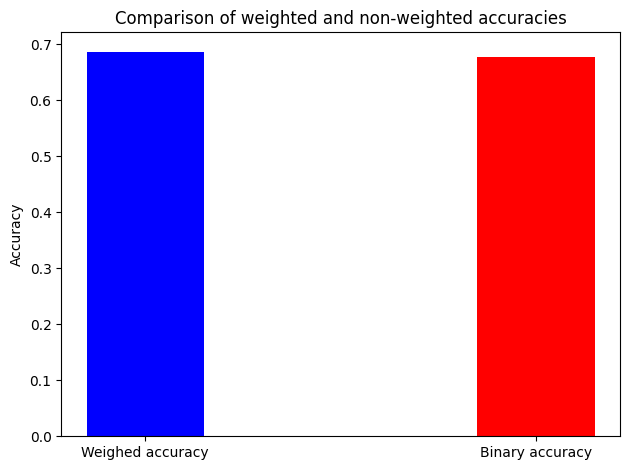

In [10]:
labels = ['Weighed accuracy', 'Binary accuracy']
token_accuracies = [token_accuracy_w, token_accuracy]

x = np.arange(len(labels))

fig, ax = plt.subplots()
rects = ax.bar(x, token_accuracies, width=0.3, color=['blue', 'red'])
ax.set_ylabel('Accuracy')
ax.set_title('Comparison of weighted and non-weighted accuracies')
ax.set_xticks(x)
ax.set_xticklabels(labels)

fig.tight_layout()
plt.show()

#### (Q1.4) A better threshold (1pt)
Above we have defined a threshold to account for an inherent bias in the dataset: there are more positive than negative words per review.
However, that threshold does not take into account *document length*. Explain why this is a problem and implement an alternative way to compute the threshold.

The current threshold approach doesn’t account for document length. Longer reviews tend to contain more sentiment-bearing words, which naturally leads to higher sentiment scores simply due to word count, not necessarily stronger sentiment. As a result, using a fixed threshold makes it more likely for longer reviews to be classified as positive or negative, even if they have a similar proportion of positive and negative words to shorter reviews. This creates inconsistency, as shorter reviews might struggle to reach the threshold, leading to possible misclassifications when strong sentiment is expressed briefly.

A better approach is to calculate a threshold (adjusted with lenght) that scales with the length of each review relative to the average length of reviews in the dataset. This can be achieved by multiplying the average bias by the ratio of the document length to the average document length. This adjustment allows the classification to focus on the sentiment ratio rather than the absolute word count, resulting in improved accuracy and consistency across reviews of different lengths.

In [11]:
def adjusted_threshold(reviews, lexicon, weight):
    tokens=[]
    scores=[]
    counts=[]

    for r in reviews:
        true=r["sentiment"]
        score, count = weighted_score(r, lexicon, weight)
        scores.append(score)
        counts.append(count)

    avg_score_a=np.mean(scores)
    avg_count_a=np.mean(counts)

    for r in reviews:
        true=r["sentiment"]
        score, count = weighted_score(r, lexicon, weight)
        threshold=avg_score_a*(count/avg_count_a)

        pred= "POS" if score>threshold else "NEG"
        tokens.append(1 if (pred=="POS" and true == "POS") or (pred == "NEG" and true == "NEG") else 0)
    return tokens, avg_score_a, avg_count_a

token_results_a, avg_score_a, avg_count_a= adjusted_threshold(reviews, lexic_dict, 2)
token_accuracy_a = sum(token_results_a)/len(token_results_a)
print("Accuracy weighted adjusted threshold: {:.2f}".format(token_accuracy_a))

Accuracy weighted adjusted threshold: 0.70


# (2) Naive Bayes (9.5pts)


Your second task is to program a simple Machine Learning approach that operates
on a simple Bag-of-Words (BoW) representation of the text data, as
described by Pang et al. (2002). In this approach, the only features we
will consider are the words in the text themselves, without bringing in
external sources of information. The BoW model is a popular way of
representing texts as vectors, making it
easy to apply classical Machine Learning algorithms on NLP tasks.
However, the BoW representation is also very crude, since it discards
all information related to word order and grammatical structure in the
original text—as the name suggests.

## Writing your own classifier (4pts)

Write your own code to implement the Naive Bayes (NB) classifier. As
a reminder, the Naive Bayes classifier works according to the following
equation:
$$\hat{c} = \operatorname*{arg\,max}_{c \in C} P(c|\bar{f}) = \operatorname*{arg\,max}_{c \in C} P(c)\prod^n_{i=1} P(f_i|c)$$
where $C = \{ \text{POS}, \text{NEG} \}$ is the set of possible classes,
$\hat{c} \in C$ is the most probable class, and $\bar{f}$ is the feature
vector. Remember that we use the log of these probabilities when making
a prediction:
$$\hat{c} = \operatorname*{arg\,max}_{c \in C} \Big\{\log P(c) + \sum^n_{i=1} \log P(f_i|c)\Big\}$$

You can find more details about Naive Bayes in [Jurafsky &
Martin](https://web.stanford.edu/~jurafsky/slp3/). You can also look at
this helpful
[pseudo-code](https://nlp.stanford.edu/IR-book/html/htmledition/naive-bayes-text-classification-1.html).

*Note: this section and the next aim to put you in a position to replicate
    Pang et al.'s Naive Bayes results. However, your numerical results
    will differ from theirs, as they used different data.*

**You must write the Naive Bayes training and prediction code from
scratch.** You will not be given credit for using off-the-shelf Machine
Learning libraries.

The data contains the text of the reviews, where each document consists
of the sentences in the review, the sentiment of the review and an index
(cv) that you will later use for cross-validation. The
text has already been tokenised and POS-tagged for you. Your algorithm
should read in the text, **lowercase it**, store the words and their
frequencies in an appropriate data structure that allows for easy
computation of the probabilities used in the Naive Bayes algorithm, and
then make predictions for new instances.


#### (Q2.1) Unseen words (1pt)
The presence of words in the test dataset that
have not been seen during training can cause probabilities in the Naive Bayes classifier to equal $0$.
These can be words which are unseen in both positive and negative training reviews (case 1), but also words which are seen in reviews _of only one sentiment class_ in the training dataset (case 2). In both cases, **you should skip these words for both classes at test time**.  What would be the problem instead with skipping words only for one class in case 2?

Words that appear in one class but not the other in the training dataset must be skipped for both classes in the test evaluation. If they are not skipped in testing, due to the training process (assuming we are using the MLE estimates for the class conditional probabilities) we will have that the estimated class conditional for an unseen word will be zero.

Let's assume we see a word $f_i$ in testing a new document, and that this word has been seen in positive reviews but not in negative.
$P(f_i | c=\text{negative}) = P_{MLE}(f_i | c=\text{negative}) = \frac{count(c=\text{negative}, f_i)}{\sum_{f \in \mathcal{F} }count(c=\text{negative}, f)} = 0$.

where $count(c, f)$ is the total count of word $f$ for documents of class $c$, and $\sum_{f \in \mathcal{F} }$ refers to a summation over all words in the collective documents.

Since the equation for Naive Bayes contains a product over all class conditionals,

$\hat{c} = \operatorname*{arg\,max}_{c \in C} P(c|\bar{f}) = \operatorname*{arg\,max}_{c \in C} P(c)\prod^n_{i=1} P(f_i|c)$

this would leave our estimated posterior class probability for the negative class at zero for any document that contains this unseen word. This word is most likely a completely feasible word to appear in a negative document, and it would be thus wrong to estimate that any documents containing this word must automatically be positive.

#### (Q2.2) Train your classifier on (positive and negative) reviews with cv-value 000-899, and test it on the remaining (positive and negative) reviews cv900–cv999.  Report results using classification accuracy as your evaluation metric. Your  features are the word vocabulary. The value of a feature is the count of that feature (word) in the document. (2pts)


In [12]:
from nltk.util import ngrams

def build_training_and_test_sets(reviews):
    pos_reviews = [r for r in reviews if r["sentiment"] == "POS"]
    neg_reviews = [r for r in reviews if r["sentiment"] == "NEG"]

    train_set = pos_reviews[:900] + neg_reviews[:900]
    test_set = pos_reviews[900:1000] + neg_reviews[900:1000]
    return train_set, test_set


def create_vocabs_count_classes(train_set):
    classes = ["POS", "NEG"]
    class_count = [0, 0]
    class_vocabs = [Counter(), Counter()]

    for review in train_set:
        # Count the number of positive and negative documents
        if review["sentiment"] == "POS":
            class_count[0] += 1
        else:
            class_count[1] += 1
        for sentence in review["content"]:
            for token, _ in sentence:
                # Count class specific words
                if review["sentiment"] == "POS":
                    class_vocabs[0][token.lower()] += 1
                else:
                    class_vocabs[1][token.lower()] += 1
    return classes, class_count, class_vocabs


def get_class_conditionals(document, class_count, class_vocabs, smoothing=0, ns=[1]):

    # Calculate prior class probabilities
    class_conditionals = [0, 0]
    class_conditionals[0] = math.log(class_count[0] / sum(class_count))
    class_conditionals[1] = math.log(class_count[1] / sum(class_count))

    # Calculate class conditional probabilities
    # Get number of words in both classes
    if smoothing != 0:
        all_words = len(set(class_vocabs[0].keys()) | set(class_vocabs[1].keys()))
    else:
        all_words = 0
    # Calculate the MLE denominator
    class_0 = math.log(sum(class_vocabs[0].values()) + smoothing*all_words)
    class_1 = math.log(sum(class_vocabs[1].values()) + smoothing*all_words)
    for sentence in document:
        # This n-grams defaults to 1-grams
        features = []
        tokens = [token.lower() for token, _ in sentence]
        for n in ns:
            features.extend(ngrams(tokens, n))
        for feature in features:
            # Combine to make a string instead of tuple
            feature = " ".join(feature)
            # Only take the tokens that are in both classes from the training set
            if feature in class_vocabs[0] and feature in class_vocabs[1]:
                # Calculate the class conditional probabilities
                class_conditionals[0] += (
                    math.log((class_vocabs[0][feature] + smoothing)) - class_0
                )
                class_conditionals[1] += (
                    math.log((class_vocabs[1][feature] + smoothing)) - class_1
                )
    return class_conditionals


def assign_class(document, classes, class_count, class_vocabs, ns):
    class_conditionals = get_class_conditionals(document, class_count, class_vocabs, smoothing=0, ns = ns)
    return classes[class_conditionals.index(max(class_conditionals))]


def evaluate_model(test_set, classes, class_count, class_vocabs, ns=[1]):
    correct = 0
    for review in test_set:
        if (
            assign_class(review["content"], classes, class_count, class_vocabs, ns)
            == review["sentiment"]
        ):
            correct += 1
    return correct / len(test_set)


def train_and_test_model(reviews):
    train_set, test_set = build_training_and_test_sets(reviews)
    classes, class_count, class_vocabs = create_vocabs_count_classes(train_set)
    accuracy = evaluate_model(test_set, classes, class_count, class_vocabs)
    return accuracy


acc = train_and_test_model(reviews)
print(f"Accuracy: {acc*100:.2f}%")

Accuracy: 82.50%


#### (Q2.3) Would you consider accuracy to also be a good way to evaluate your classifier in a situation where 90% of your data instances are of positive movie reviews? (1pt)

Simulate this scenario by keeping the positive reviews
data unchanged, but only using negative reviews cv000–cv089 for
training, and cv900–cv909 for testing. Calculate the classification
accuracy, and explain what changed.

In the space of all different kinds of classifiers, we would consider accuracy to be a bad evaluation metric because a classifer that simply evaluated all documents as positive would obtain 90% accuracy. The model would then perform badly in the real world where 90% of all reviews are assumably not positive.

In our case, after changing the reviews dataset to contain only 10% of negative reviews both in training and in testing, our classification accuracy drops to 60%. In the NB classification model, both the prior and the likelihood in the final calculation of the posterior become improperly biased when the dataset is imbalanced like this. The prior is biased towards the positive dataset, becoming 90%, and the likelihood has a much increased variance due to the total number of documents being trained on for the negative class becoming smaller. This all results in a lower classification accuracy, a reflection of the model's decreasing performance.

In [13]:
def build_training_and_test_sets_imbalanced(reviews):
    pos_reviews = [r for r in reviews if r["sentiment"] == "POS"]
    neg_reviews = [r for r in reviews if r["sentiment"] == "NEG"]

    train_set = pos_reviews[:900] + neg_reviews[:90]
    test_set = pos_reviews[900:1000] + neg_reviews[900:910]
    return train_set, test_set

def train_and_test_model_imbalanced(reviews):
    train_set, test_set = build_training_and_test_sets_imbalanced(reviews)
    classes, class_count, class_vocabs = create_vocabs_count_classes(train_set)
    accuracy = evaluate_model(test_set, classes, class_count, class_vocabs)
    return accuracy

acc = train_and_test_model_imbalanced(reviews)
print(f"Classification accuracy: {acc*100:.2f}%")

Classification accuracy: 60.00%


## Smoothing (1pt)

As mentioned above, the presence of words in the test dataset that
have not been seen during training can cause probabilities in the Naive
Bayes classifier to be $0$, thus making that particular test instance
undecidable. The standard way to mitigate this effect (as well as to
give more clout to rare words) is to use smoothing, in which the
probability fraction
$\frac{\text{count}(w_i, c)}{\sum\limits_{w\in V} \text{count}(w, c)}$ for a word
$w_i$ becomes
$\frac{\text{count}(w_i, c) + \text{smoothing}(w_i)}{\sum\limits_{w\in V} \text{count}(w, c) + \sum\limits_{w \in V} \text{smoothing}(w)}$





#### (Q2.4) Implement Laplace feature smoothing (1pt)
Implement Laplace smoothing, i.e., smoothing with a constant value ($smoothing(w) = \kappa, \forall w \in V$), in your Naive
Bayes classifier’s code, and report the accuracy.
Use $\kappa = 1$.

In [14]:
def assign_class_with_smoothing(document, classes, class_count, class_vocabs):
    class_conditionals = get_class_conditionals(document, class_count, class_vocabs, smoothing=1)
    return classes[class_conditionals.index(max(class_conditionals))]

def evaluate_model_with_smoothing(test_set, classes, class_count, class_vocabs):
    correct = 0
    for review in test_set:
        if (
            assign_class_with_smoothing(review["content"], classes, class_count, class_vocabs)
            == review["sentiment"]
        ):
            correct += 1
    return correct / len(test_set)


def train_and_test_model_with_smoothing(reviews):
    train_set, test_set = build_training_and_test_sets(reviews)
    classes, class_count, class_vocabs = create_vocabs_count_classes(train_set)
    accuracy = evaluate_model_with_smoothing(test_set, classes, class_count, class_vocabs)
    return accuracy

acc = train_and_test_model_with_smoothing(reviews)
print(acc)

0.835


## Cross-Validation (1.5pts)

A serious danger in using Machine Learning on small datasets, with many
iterations of slightly different versions of the algorithms, is ending up with Type III errors, also called the “testing hypotheses
suggested by the data” errors. This type of error occurs when we make
repeated improvements to our classifiers by playing with features and
their processing, but we don’t get a fresh, never-before seen test
dataset every time. Thus, we risk developing a classifier that gets better
and better on our data, but only gets worse at generalizing to new, unseen data. In other words, we risk developping a classifier that overfits.

A simple method to guard against Type III errors is to use
Cross-Validation. In **N-fold Cross-Validation**, we divide the data into N
distinct chunks, or folds. Then, we repeat the experiment N times: each
time holding out one of the folds for testing, training our classifier
on the remaining N - 1 data folds, and reporting performance on the
held-out fold. We can use different strategies for dividing the data:

-   Consecutive splitting:
  - cv000–cv099 = Split 1
  - cv100–cv199 = Split 2
  - etc.
  
-   Round-robin splitting (mod 10):
  - cv000, cv010, cv020, … = Split 1
  - cv001, cv011, cv021, … = Split 2
  - etc.

-   Random sampling/splitting
  - Not used here (but you may choose to split this way in a non-educational situation)



#### (Q2.5) Write the code to implement 10-fold cross-validation using round-robin splitting for your Naive Bayes classifier from Q2.4 and compute the 10 accuracies. Report the final performance, which is the average of the performances per fold. If all splits perform equally well, this is a good sign. (1pt)

In [15]:
from itertools import accumulate


def build_training_and_test_sets_cross_validation(reviews):
    num_folds = 10

    pos_reviews = [r for r in reviews if r["sentiment"] == "POS"]
    neg_reviews = [r for r in reviews if r["sentiment"] == "NEG"]

    train_sets, test_sets = [], []
    for i in range(num_folds):
        test_set = pos_reviews[i::num_folds] + neg_reviews[i::num_folds]
        train_set = [review for review in reviews if review not in test_set]
        train_sets.append(train_set)
        test_sets.append(test_set)

    return train_sets, test_sets

train_sets, test_sets = build_training_and_test_sets_cross_validation(reviews)

def train_and_test_model_cross_validation(train_sets, test_sets):
    accuracies = []

    for train_set, test_set in zip(train_sets, test_sets):
        classes, class_count, class_vocabs = create_vocabs_count_classes(train_set)
        accuracy = evaluate_model(test_set, classes, class_count, class_vocabs)
        accuracies.append(accuracy)

    return accuracies

accuracies = train_and_test_model_cross_validation(train_sets, test_sets)

print("Accuracies, 10 folds: ", accuracies)

print("Average accuracy, 10 folds: ", sum(accuracies) / len(accuracies))


Accuracies, 10 folds:  [0.775, 0.825, 0.805, 0.865, 0.78, 0.855, 0.81, 0.795, 0.825, 0.805]
Average accuracy, 10 folds:  0.8140000000000003


#### (Q2.6) Report the variance of the 10 accuracy scores. (0.5pt)

**Please report all future results using 10-fold cross-validation now
(unless told to use the held-out test set).** Note: you're not allowed to use a library for computing the variance.

In [16]:
variance = sum((acc - sum(accuracies) / len(accuracies))**2 for acc in accuracies) / len(accuracies)

print(variance)

0.0007739999999999989


## Features, overfitting, and the curse of dimensionality

In the Bag-of-Words model, ideally we would like each distinct word in
the text to be mapped to its own dimension in the output vector
representation. However, real world text is messy, and we need to decide
on what we consider to be a word. For example, is “`word`" different
from “`Word`", from “`word`”, or from “`words`"? Too strict a
definition, and the number of features explodes, while our algorithm
fails to learn anything generalisable. Too lax, and we risk destroying
our learning signal. In the following section, you will learn about
confronting the feature sparsity and the overfitting problems as they
occur in NLP classification tasks.

### Stemming (1.5pts)

To make your algorithm more robust, use stemming and hash different inflections of a word to the same feature in the BoW vector space. Please use the [Porter stemming
    algorithm](http://www.nltk.org/howto/stem.html) from NLTK.



In [17]:
from nltk.stem.porter import PorterStemmer
import copy

def stem_reviews(reviews):
    new_reviews = copy.deepcopy(reviews)
    stemmer = PorterStemmer()
    for review in new_reviews:
        for sentence in review["content"]:
            for i, (token, pos_tag) in enumerate(sentence):
                sentence[i] = (stemmer.stem(token), pos_tag)
    return new_reviews

show_document_statistics(reviews)

reviews_stemmed = stem_reviews(reviews)

show_document_statistics(reviews_stemmed)

Total number of reviews: 2000 

0 NEG 29
Two/CD teen/JJ couples/NNS go/VBP to/TO a/DT church/NN party/NN ,/, drink/NN and/CC then/RB drive/NN ./.
1 NEG 11
Damn/JJ that/IN Y2K/CD bug/NN ./.
2 NEG 24
It/PRP is/VBZ movies/NNS like/IN these/DT that/WDT make/VBP a/DT jaded/JJ movie/NN viewer/NN thankful/JJ for/IN the/DT invention/NN of/IN the/DT Timex/NNP IndiGlo/NNP watch/NN ./.
3 NEG 19
QUEST/NN FOR/IN CAMELOT/NNP ``/`` Quest/NNP for/IN Camelot/NNP ''/'' is/VBZ Warner/NNP Bros./NNP '/POS first/JJ feature-length/JJ ,/, fully-animated/JJ attempt/NN to/TO steal/VB clout/NN from/IN Disney/NNP 's/POS cartoon/NN empire/NN ,/, but/CC the/DT mouse/NN has/VBZ no/DT reason/NN to/TO be/VB worried/VBN ./.
4 NEG 38
Synopsis/NNPS :/: A/DT mentally/RB unstable/JJ man/NN undergoing/VBG psychotherapy/NN saves/VBZ a/DT boy/NN from/IN a/DT potentially/RB fatal/JJ accident/NN and/CC then/RB falls/VBZ in/IN love/NN with/IN the/DT boy/NN 's/POS mother/NN ,/, a/DT fledgling/NN restauranteur/NN ./.
5 NEG 35
In/I

#### (Q2.7): How does the performance of your classifier change when you use stemming on your training and test datasets? (1pt)
Use cross-validation to evaluate the classifier.


In [18]:
train_sets, test_sets = build_training_and_test_sets_cross_validation(reviews_stemmed)
accuracies = train_and_test_model_cross_validation(train_sets, test_sets)
print("Accuracies, 10 folds: ", accuracies)

print("Average accuracy, 10 folds: ", sum(accuracies) / len(accuracies))

variance = sum((acc - sum(accuracies) / len(accuracies))**2 for acc in accuracies) / len(accuracies)

print(variance)

Accuracies, 10 folds:  [0.775, 0.835, 0.805, 0.865, 0.785, 0.845, 0.805, 0.785, 0.83, 0.815]
Average accuracy, 10 folds:  0.8145
0.0007622499999999988


#### (Q2.8) What happens to the number of features (i.e., the size of the vocabulary) when using stemming as opposed to (Q2.4)? (0.5pt)
Give actual numbers. You can use the held-out training set to determine these.

In [19]:
def get_num_features(train_set):
    c = Counter()
    for review in train_set:
        for sentence in review["content"]:
            for token, _ in sentence:
                c[token.lower()] += 1
    return len(c)

train_set, _ = build_training_and_test_sets(reviews)
train_set_stemmed, _ = build_training_and_test_sets(reviews_stemmed)

num_features = get_num_features(train_set)
num_features_stemmed = get_num_features(train_set_stemmed)

print("Number of features before stemming: ", num_features)
print("Number of features after stemming: ", num_features_stemmed)

Number of features before stemming:  45348
Number of features after stemming:  32404


### N-grams (1.5pts)

A simple way of retaining some of the word
order information when using bag-of-words representations is to use **n-gram** features.







#### (Q2.9) Retrain your classifier from (Q2.4) using **unigrams+bigrams** and **unigrams+bigrams+trigrams** as features. (1pt)
Report accuracy and compare it with that of the approaches you have previously implemented. You are allowed to use NLTK to build n-grams from sentences.

In [20]:
from nltk.util import ngrams

def extract_ngram_features(review, ns):
    features = []
    for sentence in review['content']:
        tokens = [token.lower() for token, _ in sentence]
        for n in ns:
            features.extend(ngrams(tokens, n))
    return features

def create_vocabs_count_classes_ngram(train_set, ns):
    classes = ["POS", "NEG"]
    class_count = [0, 0]
    class_vocabs = [Counter(), Counter()]

    for review in train_set:
        # Count the number of positive and negative documents
        if review["sentiment"] == "POS":
            class_count[0] += 1
        else:
            class_count[1] += 1
        for ngram in extract_ngram_features(review, ns):
            ngram = " ".join(ngram)
            # Count class specific words
            if review["sentiment"] == "POS":
                class_vocabs[0][ngram] += 1
            else:
                class_vocabs[1][ngram] += 1
    return classes, class_count, class_vocabs

def train_and_test_model_ngram(train_sets, test_sets, ns):
    # Default is cross validation
    accuracies = []

    for train_set, test_set in zip(train_sets, test_sets):
        classes, class_count, class_vocabs = create_vocabs_count_classes_ngram(train_set, ns)
        accuracy = evaluate_model(test_set, classes, class_count, class_vocabs, ns)
        accuracies.append(accuracy)

    return accuracies

# Get cross-validation train and test sets
train_sets, test_sets = build_training_and_test_sets_cross_validation(reviews)

# Unigrams + bigrams
accuracies = train_and_test_model_ngram(train_sets, test_sets, [1,2])

print("Accuracies, unigrams+bigrams, 10 folds: ", accuracies)

print("Average accuracy, unigrams+bigrams, 10 folds: ", sum(accuracies) / len(accuracies))

variance = sum((acc - sum(accuracies) / len(accuracies))**2 for acc in accuracies) / len(accuracies)

print("Variance, unigrams+bigrams: ", variance)


# Unigrams + bigrams + trigrams
accuracies = train_and_test_model_ngram(train_sets, test_sets, [1,2,3])

print("Accuracies, unigrams+bigrams+trigrams, 10 folds: ", accuracies)

print("Average accuracy, unigrams+bigrams+trigrams, 10 folds: ", sum(accuracies) / len(accuracies))

variance = sum((acc - sum(accuracies) / len(accuracies))**2 for acc in accuracies) / len(accuracies)

print("Variance, unigrams+bigrams+trigrams: ", variance)

Accuracies, unigrams+bigrams, 10 folds:  [0.79, 0.86, 0.79, 0.865, 0.8, 0.855, 0.825, 0.81, 0.82, 0.835]
Average accuracy, unigrams+bigrams, 10 folds:  0.825
Variance, unigrams+bigrams:  0.0007149999999999987
Accuracies, unigrams+bigrams+trigrams, 10 folds:  [0.785, 0.855, 0.815, 0.865, 0.785, 0.865, 0.83, 0.815, 0.85, 0.83]
Average accuracy, unigrams+bigrams+trigrams, 10 folds:  0.8295
Variance, unigrams+bigrams+trigrams:  0.0007972499999999996



#### Q2.10: How many features does the BoW model have to take into account now? (0.5pt)
How would you expect the number of features to increase theoretically (e.g., linear, square, cubed, exponential)? How do the number of features increase in the held-out training set (compared to Q2.8)? Do you expect this rate of increase to continue for (much) larger n-grams?

Use the held-out training set once again for this.


Theoretically, we expect the number of features to increase exponentially with n. This is because there are $V^n$ number of possible combinations of words to create an n-gram.

However, we see here that the actual increase of features is far less than the expected exponential growth. We see that the number of features for unigrams starts at 45348, then increases to 465262 after including bigrams, and then to 1346107 after including trigrams.

This is because we do not see all possible combinations of words in the training set(nor would we expect to. For example, you would see the combination "North Holland" but would expect to rarely see the combination "Holland North".). As we see larger and larger n-grams, I would expect the increase in features to taper off until we reach the limit of the largest sentence length, due to this reason.

In [21]:
train_set, _ = build_training_and_test_sets(reviews)

uni = len(create_vocabs_count_classes_ngram(train_set, [1])[2][0] + create_vocabs_count_classes_ngram(train_set, [1])[2][1])
unibi = len(create_vocabs_count_classes_ngram(train_set, [1,2])[2][0] + create_vocabs_count_classes_ngram(train_set, [1,2])[2][1])
unibitri = len(create_vocabs_count_classes_ngram(train_set, [1,2,3])[2][0] + create_vocabs_count_classes_ngram(train_set, [1,2,3])[2][1])
print(f"Number of features, unigrams: {uni}")
print(f"Number of features, unigrams+bigrams: {unibi}")
print(f"Number of features, unigrams+bigrams+trigrams: {unibitri}")

Number of features, unigrams: 45348
Number of features, unigrams+bigrams: 465262
Number of features, unigrams+bigrams+trigrams: 1346107


# (3) Support Vector Machines (4pts)

Though simple to understand, implement, and debug, one
major problem with the Naive Bayes classifier is that its performance
deteriorates (becomes skewed) when it is being used with features which
are not independent (i.e., are correlated). Another popular classifier
that doesn’t scale as well to big data, and is not as simple to debug as
Naive Bayes, but that doesn’t assume feature independence is the Support
Vector Machine (SVM) classifier.

You can find more details about SVMs in Chapter 7 of Bishop: Pattern Recognition and Machine Learning.
Other sources for learning SVM:
* http://web.mit.edu/zoya/www/SVM.pdf
* http://www.cs.columbia.edu/~kathy/cs4701/documents/jason_svm_tutorial.pdf
* https://pythonprogramming.net/support-vector-machine-intro-machine-learning-tutorial/







Use the scikit-learn implementation of
[SVM](http://scikit-learn.org/stable/modules/svm.html) with the default parameters. (You are not expected to perform any hyperparameter tuning, but feel free to do it if you think it gives you good insights for the discussion in question 5.)



#### (Q3.1): Train SVM and compare to Naive Bayes (2pts)

Train an SVM classifier (sklearn.svm.LinearSVC) using the features collected for Naive Bayes. Compare the
classification performance of the SVM classifier to that of the Naive
Bayes classifier with smoothing.
Use cross-validation to evaluate the performance of the classifiers.



In [22]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import LinearSVC

def extract_features(reviews, vectorizer=None):
    # Extracts unigram features from the review content.
    documents = [" ".join([token.lower() for sentence in review['content'] for token, _ in sentence]) for review in reviews]
    if vectorizer is None:
        vectorizer = CountVectorizer(ngram_range=(1, 1))  # Fixed to use unigrams
        X = vectorizer.fit_transform(documents)
    else:
        X = vectorizer.transform(documents)
    y = [1 if review["sentiment"] == "POS" else 0 for review in reviews]
    return X, y, vectorizer

def build_training_and_test_sets_cross_validation(reviews):
    # Splits reviews into 10-fold cross-validation training and test sets.
    num_folds = 10
    pos_reviews = [r for r in reviews if r["sentiment"] == "POS"]
    neg_reviews = [r for r in reviews if r["sentiment"] == "NEG"]

    train_sets, test_sets = [], []
    for i in range(num_folds):
        test_set = pos_reviews[i::num_folds] + neg_reviews[i::num_folds]
        train_set = [review for review in reviews if review not in test_set]
        train_sets.append(train_set)
        test_sets.append(test_set)

    return train_sets, test_sets

def train_and_test_model_cross_validation_svm(train_sets, test_sets, feature_extraction_func):
    # Trains an SVM classifier using cross-validation and returns the accuracies for each fold.
    accuracies = []

    for train_set, test_set in zip(train_sets, test_sets):
        X_train, y_train, vectorizer = feature_extraction_func(train_set)
        X_test, y_test, _ = feature_extraction_func(test_set, vectorizer=vectorizer)
        svm = LinearSVC(dual='auto', max_iter=10000)
        svm.fit(X_train, y_train)
        accuracy = svm.score(X_test, y_test)
        accuracies.append(accuracy)

    return accuracies

def print_results(label, accuracies):
    # Prints the average accuracy and variance of accuracies across cross-validation folds for the specified label.
    mean_accuracy = np.mean(accuracies)
    variance = np.var(accuracies)
    print(f"{label}:")
    print("Accuracies, 10 folds: ", accuracies)
    print("Average accuracy, 10 folds: ", mean_accuracy * 100)
    print("Variance of accuracies, 10 folds: ", variance)

train_sets, test_sets = build_training_and_test_sets_cross_validation(reviews)

print("=== SVM ===")
print_results("SVM with Unigram", train_and_test_model_cross_validation_svm(train_sets, test_sets, extract_features))


=== SVM ===
SVM with Unigram:
Accuracies, 10 folds:  [0.815, 0.815, 0.805, 0.855, 0.845, 0.835, 0.865, 0.84, 0.855, 0.81]
Average accuracy, 10 folds:  83.39999999999999
Variance of accuracies, 10 folds:  0.00041399999999999955


| Model       | Average Accuracy (10 folds) | Variance of Accuracies (10 folds) |
|-------------|------------------------------|-----------------------------------|
| Naive Bayes | 81.40%                       | 0.000774                          |
| SVM Unigram        | 83.40%                       | 0.000414                          |

The SVM classifier achieves a higher average accuracy (83.40%) and greater stability (variance of 0.000414) compared to the Naive Bayes classifier (81.40% accuracy, 0.000774 variance). This indicates that SVM is better at classifying sentiment consistently across different folds. SVM's advantage lies in its ability to find an optimal hyperplane that maximizes the margin between classes, allowing for more accurate and confident predictions. In contrast, Naive Bayes, with its assumption of feature independence, may struggle when features are correlated, leading to slightly less robust performance on complex text data.

### POS disambiguation (2pts)

Now add in part-of-speech features. You will find the
movie review dataset has already been POS-tagged for you ([here](https://catalog.ldc.upenn.edu/docs/LDC99T42/tagguid1.pdf) you find the tagset). Try to
replicate the results obtained by Pang et al. (2002).



#### (Q3.2) Replace your features with word+POS features, and report performance with the SVM. Use cross-validation to evaluate the classifier and compare the results with (Q3.1). Does part-of-speech information help? Explain why this may be the case. (1pt)


In [23]:
def extract_features_with_pos(reviews, vectorizer=None):
    # Extracts unigram features with POS tagging from the review content.
    documents = [
        " ".join(["_".join((token.lower(), pos_tag)) for sentence in review['content'] for token, pos_tag in sentence])
        for review in reviews
    ]
    if vectorizer is None:
        vectorizer = CountVectorizer(ngram_range=(1, 1))  # Fixed to use unigrams
        X = vectorizer.fit_transform(documents)
    else:
        X = vectorizer.transform(documents)
    y = [1 if review["sentiment"] == "POS" else 0 for review in reviews]
    return X, y, vectorizer

print("\n=== SVM + POS ===")
print_results("SVM with Word + POS Unigram", train_and_test_model_cross_validation_svm(train_sets, test_sets, extract_features_with_pos))



=== SVM + POS ===
SVM with Word + POS Unigram:
Accuracies, 10 folds:  [0.82, 0.825, 0.835, 0.85, 0.835, 0.835, 0.855, 0.86, 0.85, 0.83]
Average accuracy, 10 folds:  83.94999999999999
Variance of accuracies, 10 folds:  0.00016225000000000028


| Model                     | Average Accuracy (10 folds) | Variance of Accuracies (10 folds) |
|---------------------------|-----------------------------|-----------------------------------|
| Naive Bayes               | 81.40%                      | 0.000774                          |
| SVM Unigram               | 83.40%                      | 0.000414                          |
| SVM with Word + POS Unigram | 83.95%                    | 0.000162                          |

Including part-of-speech (POS) information helps improve the model's performance. The average accuracy for the SVM with Word + POS Unigram is 83.95%, which is higher than the 83.4% achieved by the SVM with standard unigrams. Additionally, the variance of the accuracies with POS information is 0.000162, lower than the 0.000414 variance without POS. This indicates that the model's performance is more consistent across the folds when POS information is included.
POS tagging enriches the feature set by providing context about the syntactic role of each word in a sentence. This context allows the model to better differentiate words that may carry different meanings or importance depending on their grammatical role. Including POS tags helps the model understand these relationships and generate more informative and distinctive features, leading to better classification performance as observed in the results.

#### (Q3.3) Discard all closed-class words from your data (keep only nouns, verbs, adjectives, and adverbs), and report performance. Does this help? Use cross-validation to evaluate the classifier and compare the results with (Q3.2). Are closed-class words detrimental to the classifier? Explain why this may be the case. (1pt)

In [24]:
OPEN_CLASS_TAGS = {'NN', 'NNS', 'NNP', 'NNPS', 'VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ', 'JJ', 'JJR', 'JJS', 'RB', 'RBR', 'RBS'}

def extract_features_ngram_open_class(reviews, vectorizer=None):
    # Extracts unigram features with POS tagging from open-class words in the review content.
    documents = [
        " ".join(["_".join((token.lower(), pos_tag)) for sentence in review['content'] for token, pos_tag in sentence if pos_tag in OPEN_CLASS_TAGS])
        for review in reviews
    ]
    if vectorizer is None:
        vectorizer = CountVectorizer(ngram_range=(1, 1))  # Fixed to use unigrams
        X = vectorizer.fit_transform(documents)
    else:
        X = vectorizer.transform(documents)
    y = [1 if review["sentiment"] == "POS" else 0 for review in reviews]
    return X, y, vectorizer

print("\n=== SVM + POS (Open-Class Words) ===")
print_results("SVM with Word + POS (Open-Class Words) Unigram", train_and_test_model_cross_validation_svm(train_sets, test_sets, extract_features_ngram_open_class))


=== SVM + POS (Open-Class Words) ===
SVM with Word + POS (Open-Class Words) Unigram:
Accuracies, 10 folds:  [0.835, 0.835, 0.825, 0.835, 0.855, 0.825, 0.885, 0.855, 0.85, 0.835]
Average accuracy, 10 folds:  84.35
Variance of accuracies, 10 folds:  0.0003002500000000005


| Model                                | Average Accuracy (10 folds) | Variance of Accuracies (10 folds) |
|--------------------------------------|-----------------------------|-----------------------------------|
| Naive Bayes                          | 81.40%                      | 0.000774                          |
| SVM Unigram                          | 83.40%                      | 0.000414                          |
| SVM with Word + POS Unigram          | 83.95%                      | 0.000162                          |
| SVM with Word + POS (Open-Class Words) Unigram | 84.35%            | 0.000300                          |

When comparing the results of the SVM with POS for all words and the SVM with POS for open-class words, we observe that focusing on open-class words improves the model's performance. The average accuracy for the SVM with Word + POS (Open-Class Words) Unigram is 84.35%, which is higher than the 83.95% observed for the SVM with Word + POS Unigram including all words. The variance for the open-class version is 0.000300, slightly higher than the 0.000162 for the model using all words, but this increase is minor and does not significantly impact stability.
Closed-class words, such as conjunctions, prepositions, articles, and pronouns, may reduce the effectiveness of the classifie because they typically do not carry significant semantic information related to sentiment. These words function more for grammatical structure than for content, which means they add noise to the feature set without contributing much to distinguishing between positive and negative sentiment. By focusing only on open-class words, which include nouns, verbs, adjectives, and adverbs, the model uses more informative and sentiment-relevant features. This likely explains why the classifier's performance improves when closed-class words are excluded, leading to a higher average accuracy.

# (4) Discussion (max. 500 words). (5pts)

> Based on your experiments, what are the effective features and techniques in sentiment analysis? What information do different features encode?
Why is this important? What are the limitations of these features and techniques?



The lexicon-based approach uses a predefined lexicon to classify the sentiment of movie reviews, offering a straightforward solution without needing training. In binary scoring, positive and negative words are counted, and a review is classified as positive if the positive word count exceeds a threshold of 8, providing a basic level of sentiment classification. Weighted scoring, which considers the strength of sentiment words, enhances performance by giving stronger words a greater impact. An adjusted threshold that scales according to review length further improves accuracy, allowing the model to adapt to the number of sentiment-bearing words in each review. However, this method lacks contextual understanding and cannot handle negation well. Additionally, it is limited by the lexicon's coverage, which affects performance and restricts the model's ability to interpret complex language, partly due to the lack of global context beyond the document's scope.

The Naive Bayes classifier estimates class probabilities by calculating maximum likelihood estimates of word probabilities per class and prior document class distributions. Specifically, it uses word counts per class as the features of the model. We then choose the class with the higher computed posterior probability as the prediction. In experiments, we used n-grams and stemming as alternative features. N-grams represent n-length combinations of words, retaining the word order, while stemming removes morphological affixes, leaving word stems as features. We observed slight improvements with n-grams, likely due to the added contextual information. However, the limited improvement can be attributed to the rarity of encountering a specific sequence of words during testing that was previously seen in training, which becomes more pronounced as n increases, limiting n-grams' effectiveness in capturing context. Stemming did not result in any accuracy improvements; although it creates more accurate word counts, it also reduces feature information.

We trained a linear SVM on the same features used in Naive Bayes, where each review was transformed into a vector based on word frequencies. This achieved better accuracy than Naive Bayes, potentially indicating that accounting for correlations among words in documents could be relevant to the class. Adding part-of-speech tags, which provide grammatical context, further improved accuracy by helping the model resolve ambiguities in meaning. Restricting the model to open-class words increased accuracy as the removed words added noise and contributed little sentiment-bearing information.

To conclude, bag-of-words models, such as those used in our experiment, do not correctly handle negation and ignore word order and deeper syntactic relationships, which are often essential for classifying sentiment. Sparsity also negatively impacts training. For example, in Naive Bayes, we skip words and n-grams unseen in training, and in SVMs, the sparse data in high-dimensional feature space can lead to overfitting.
SVM outperforms lexicon-based and Naive Bayes models, potentially due to dropping the assumption of conditional independence. Further enhancements, such as contextual embedding, could lead to more accurate sentiment classification.


| Model                                | Average Accuracy (10 folds) | Variance of Accuracies (10 folds) |
|--------------------------------------|-----------------------------|-----------------------------------|
| Naive Bayes                          | 81.40%                      | 0.000774                          |
| Naive Bayes + Stemming               | 81.45%                      | 0.000762                          |
| Naive Bayes Unigrams + Bigrams       | 82.50%                      | 0.000715                          |
| Naive Bayes Unigrams + Bigrams + Trigrams      | 82.95%                      | 0.000797                |
| SVM Unigram                          | 83.40%                      | 0.000414                          |
| SVM with Word + POS Unigram          | 83.95%                      | 0.000162                          |
| SVM with Word + POS (Open-Class Words) Unigram | 84.35%            | 0.000300                          |

| Lexicon Models                               | Accuracy |
|--------------------------------------|-----------------------------|
| Lexicon                | 68.00%                      |
| Lexicon Weighed             | 69.00%                      |
| Lexicon Weighted Adjusted Threshold       | 70.00%                      |

# Submission


In [25]:
# Write your names and student numbers here:
#John Yao 15667839
#Alisia Baielli 15823725

**That's it!**

- Check if you answered all questions fully and correctly.
- Download your completed notebook using `File -> Download .ipynb`
- Check if your answers are all included in the file you submit.
- Submit your .ipynb file via *Canvas*. One submission per group.